# Day 6: Error Analysis and Probability Calibration

A high ROC-AUC score means our model ranks Higgs events higher than Z boson events. However, it does not guarantee that the predicted probabilities are *accurate*. In experimental physics, if an algorithm states it is 90% confident an event is a Higgs, it must be correct exactly 9 out of 10 times. Today, we map our errors and calibrate our statistical confidence.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

print("Loading Data and Production Model...")

df = pd.read_csv('training.csv').replace(-999.0, np.nan)
cols_to_drop = df.columns[df.isna().mean() > 0.70].tolist() + ['EventId', 'Weight']
df_clean = df.drop(columns=cols_to_drop)

for col in df_clean.columns:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean['Label'] = df_clean['Label'].map({'s': 1, 'b': 0})
X = df_clean.drop(columns=['Label'])
y = df_clean['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
scaler.fit(X_train) 
X_test_scaled = scaler.transform(X_test)

final_xgb = XGBClassifier()
final_xgb.load_model('models/higgs_classifier_v1.json')

y_pred = final_xgb.predict(X_test_scaled)
y_prob = final_xgb.predict_proba(X_test_scaled)[:, 1]

print("Ready for Analysis.")

Loading Data and Production Model...
Ready for Analysis.


## 1. Mapping the Information Leakage (Confusion Matrix)
We visualize the exact number of collisions where the missing neutrino energy caused our algorithm to incorrectly classify the event.
* **Type I Error (False Discovery):** A standard $Z$ boson mimicking a Higgs.
* **Type II Error (Missed Signal):** A true Higgs whose kinematics were too smeared to detect.

<Figure size 800x600 with 0 Axes>

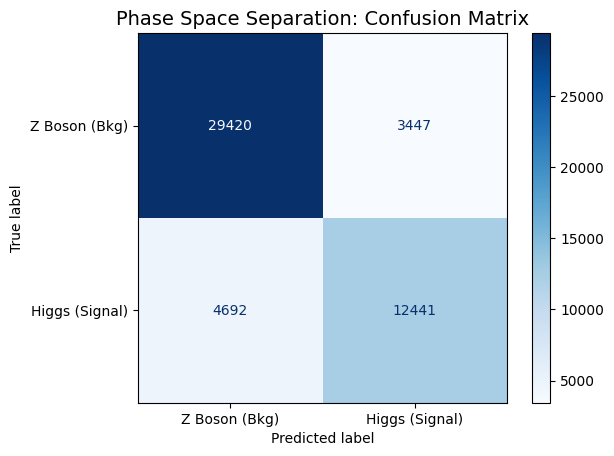

False Discovery Rate (Contamination in Signal Region): 21.70%
Missed Signal Rate (Lost Higgs Bosons): 13.75%


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Z Boson (Bkg)', 'Higgs (Signal)'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Phase Space Separation: Confusion Matrix", fontsize=14)
plt.show()

false_discovery_rate = cm[0, 1] / (cm[0, 1] + cm[1, 1])
missed_signal_rate = cm[1, 0] / (cm[1, 0] + cm[0, 0])

print(f"False Discovery Rate (Contamination in Signal Region): {false_discovery_rate:.2%}")
print(f"Missed Signal Rate (Lost Higgs Bosons): {missed_signal_rate:.2%}")

## 2. The Reliability Diagram
Does 90% confidence actually equal 90% accuracy? We group our predictions into 10 probability "bins" and calculate the true fraction of Higgs bosons inside each bin. A perfectly calibrated model will sit exactly on the $y=x$ diagonal.

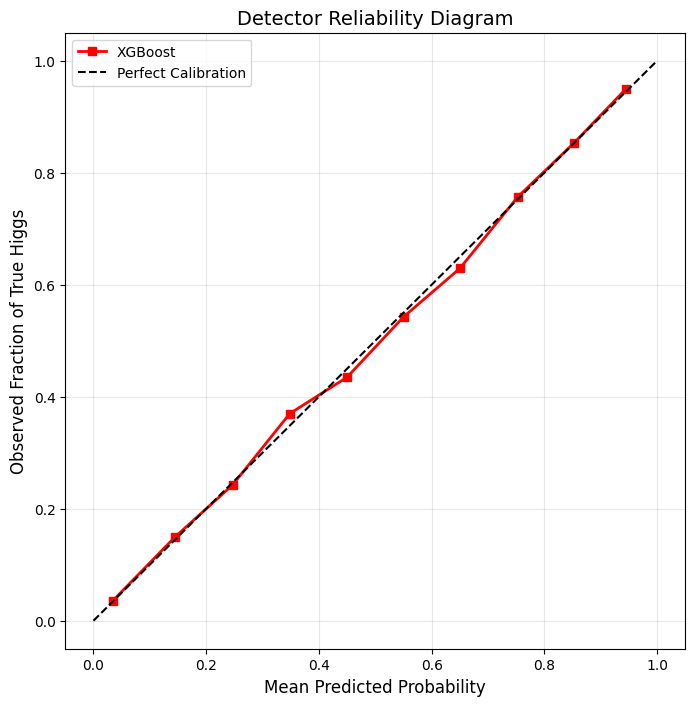

Model Brier Score (Lower is better): 0.1150


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(8, 8))
plt.plot(prob_pred, prob_true, marker='s', label='XGBoost', color='red', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration', color='black')

plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Observed Fraction of True Higgs', fontsize=12)
plt.title('Detector Reliability Diagram', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

brier = brier_score_loss(y_test, y_prob)
print(f"Model Brier Score (Lower is better): {brier:.4f}")